In [33]:
import requests
import pandas as pd
import numpy as np
import os
import tarfile
import json
import matplotlib.pyplot as plt

from google.colab import drive
from dotenv import load_dotenv

### 1. 데이터 불러오기

1. huggingFace에서 받아온 데이터 drive에서 불러오기
2. 파일 압축 해제 후 데이터 읽기

In [34]:
# Google Drive 마운트
drive.mount('/content/drive')

# 압축 파일 경로
ppg_tar_path = '/content/drive/MyDrive/ColabNotebooks/kakao/ppg-bp-dataset.tar.gz'

# 압축 해제
extract_path = "/content/ppg-bp-dataset"

with tarfile.open(ppg_tar_path, "r:gz") as tar:
    tar.extractall(extract_path)

# jsonl 파일 경로
jsonl_path = f"{extract_path}/content/ppgtrialscsv.jsonl"

# jsonl 읽기
records = []

with open(jsonl_path, "r") as f:
    for line in f:
        records.append(json.loads(line))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_3842/1199495777.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


In [35]:
# DataFrame 생성
df = pd.DataFrame(records)

### 2. 데이터 변환

In [36]:
# 숫자형 변환
df["SBP"] = pd.to_numeric(df["SBP"])
df["DBP"] = pd.to_numeric(df["DBP"])

# 샘플 순서를 시간축처럼 사용
df["time_index"] = range(len(df))

print(df.head())
print(df.info())

                 img         SBP        DBP  time_index
0  cwt_image_1_0.png  145.766071  59.609919           0
1  cwt_image_1_1.png  148.460218  59.937821           1
2  cwt_image_1_2.png  148.258138  60.710508           2
3  cwt_image_1_3.png  147.246658  60.043770           3
4  cwt_image_1_4.png  144.831927  51.490844           4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11728 entries, 0 to 11727
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   img         11728 non-null  object 
 1   SBP         11728 non-null  float64
 2   DBP         11728 non-null  float64
 3   time_index  11728 non-null  int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 366.6+ KB
None


### 3. 데이터 시각화

- PPG 데이터로부터 추출된 혈압 라벨(SBP, DBP)이 샘플 순서에 따라 어떻게 변하는지 시각화
- SBP (수축기 혈압) / DBP (이완기 혈압)

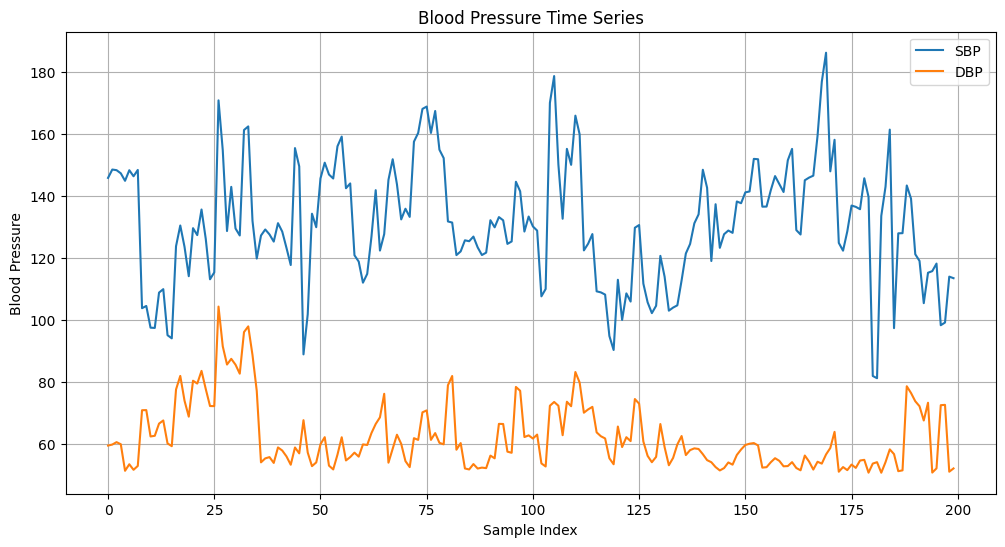

In [37]:
sample_df = df.iloc[:200]

plt.figure(figsize=(12, 6))

plt.plot(sample_df["time_index"], sample_df["SBP"], label="SBP")
plt.plot(sample_df["time_index"], sample_df["DBP"], label="DBP")

plt.title("Blood Pressure Time Series")
plt.xlabel("Sample Index")
plt.ylabel("Blood Pressure")

plt.legend()
plt.grid(True)

plt.show()